In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [10]:
df=pd.read_csv(r"C:\Users\kolhe\Downloads\Mall_Customers.csv")

In [11]:
X = df.drop('CustomerID', axis=1)
le = LabelEncoder()
X['Gender'] = le.fit_transform(X['Gender'])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

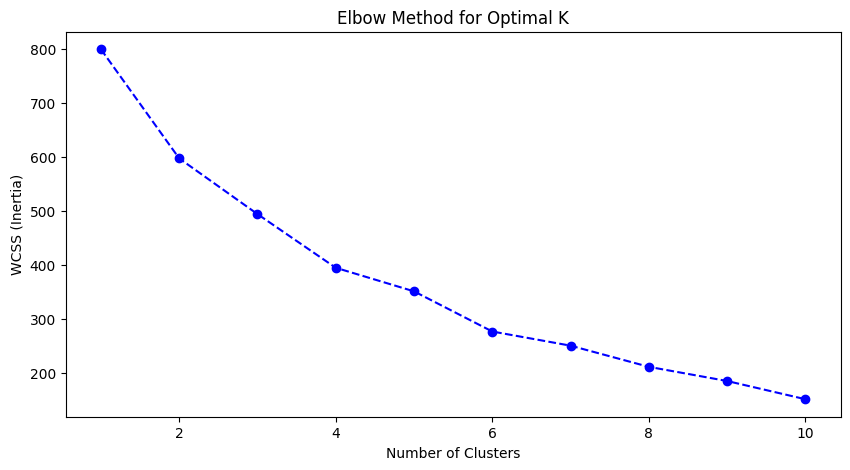

In [12]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

In [13]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)
print(f"Silhouette Score: {silhouette_score(X_scaled, clusters):.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(X_scaled, clusters):.4f}")

Silhouette Score: 0.2901
Davies-Bouldin Score: 1.3056


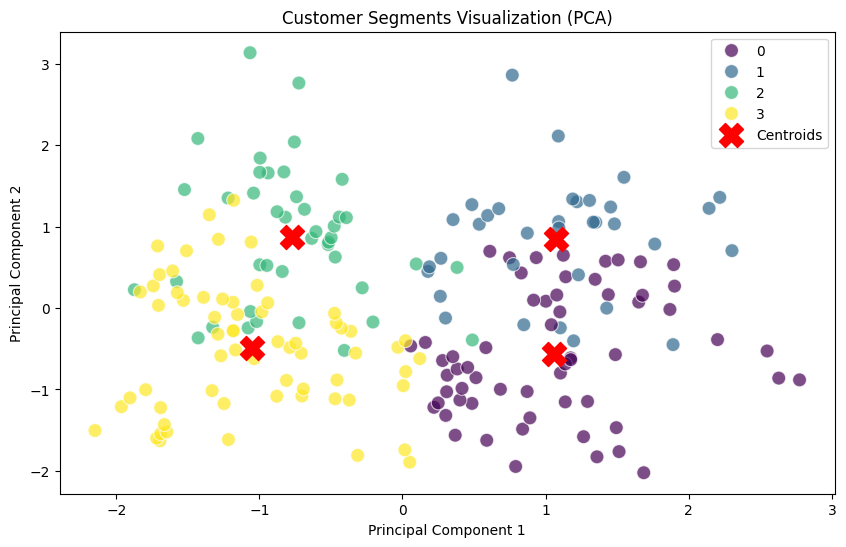

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', s=100, alpha=0.7)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('Customer Segments Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

Cluster Profiles:
                Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        54.700000           46.900000               39.933333
1        41.264706           88.500000               16.764706
2        28.690476           60.904762               70.238095
3        29.375000           58.296875               64.437500


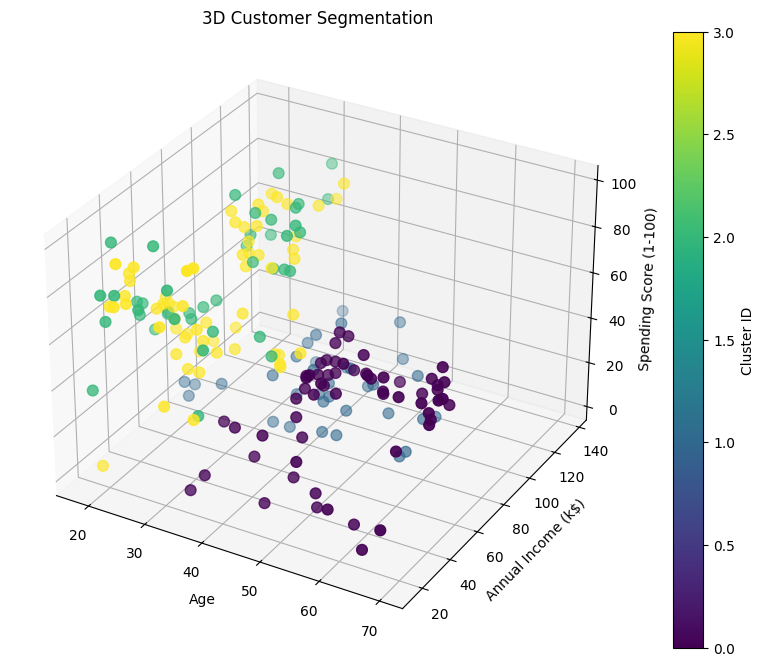

In [16]:
from mpl_toolkits.mplot3d import Axes3D

# Generate Cluster Profiles
df['Cluster'] = kmeans.labels_
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print("Cluster Profiles:\n", profile)

# 3D Visualization
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using original features
scatter = ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                     c=df['Cluster'], cmap='viridis', s=60)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
plt.title('3D Customer Segmentation')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

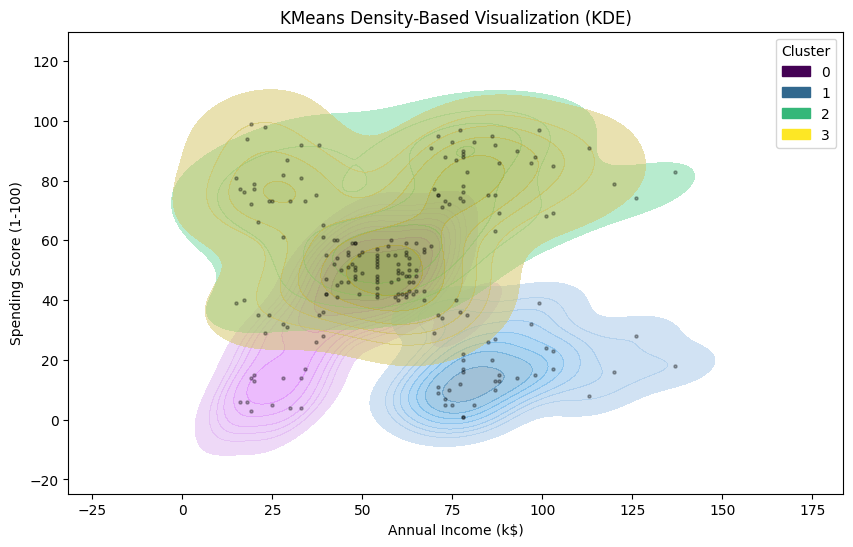

In [20]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
            hue='Cluster', fill=True, palette='viridis', alpha=0.5)
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c='black', s=5, alpha=0.3)
plt.title("KMeans Density-Based Visualization (KDE)")
plt.show()